# 3.2 线性回归的从零开始实现 (Linear Regression from Scratch)
> 对应教材《动手学深度学习》(PyTorch版) 第3.2节。  
> 严格提取教材中的代码实现，仅使用原生张量运算和自动微分，完整搭建合成数据流水线、迭代器、线性模型、损失函数、SGD优化器与训练循环，并附带 7 道课后练习题的仿真验证。


In [1]:
# 【所属小节】3.2 线性回归的从零开始实现 - 导入必要软件包
# 【作用说明】导入 random 模块用于样本索引打乱、导入 torch 核心库以及 d2l 绘图工具包
%matplotlib inline
import random
import torch
from d2l import torch as d2l


In [2]:
# 【所属小节】3.2.1 生成数据集 - 合成带高斯噪声的数据集
# 【作用说明】根据线性模型 y = Xw + b + 噪声 生成 1000 个带噪声的合成样本
def synthetic_data(w, b, num_examples):
    #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features[0]:', features[0], '\nlabel[0]:', labels[0])


features[0]: tensor([-0.1328, -0.2910]) 
label[0]: tensor([4.9169])


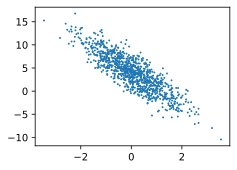

In [3]:
# 【所属小节】3.2.1 生成数据集 - 可视化特征与标签的线性相关性
# 【作用说明】绘制第二个特征 features[:, 1] 与 labels 的散点图，直观验证斜率为 -3.4 的线性关系
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);


In [4]:
# 【所属小节】3.2.2 读取数据集 - 小批量数据迭代生成器
# 【作用说明】打乱样本索引列表，并按 batch_size 批量步长切片切出特征与标签
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# 测试读取第一个小批量并打印形状
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print("第一个小批量的 X 形状:", X.shape, "\n第一个小批量的 y 形状:", y.shape)
    print("X 样本前两行:\n", X[:2])
    print("y 样本前两行:\n", y[:2])
    break


第一个小批量的 X 形状: torch.Size([10, 2]) 
第一个小批量的 y 形状: torch.Size([10, 1])
X 样本前两行:
 tensor([[-0.4252,  1.3203],
        [ 0.7876,  0.2243]])
y 样本前两行:
 tensor([[-1.1317],
        [ 5.0246]])


In [5]:
# 【所属小节】3.2.3 初始化模型参数
# 【作用说明】从均值为 0、标准差为 0.01 的正态分布中采样初始化权重 w，将偏置 b 初始化为 0，并开启 requires_grad 追踪梯度
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)


In [6]:
# 【所属小节】3.2.4 定义模型
# 【作用说明】定义线性回归仿射变换前向传播公式 y = Xw + b，标量 b 自动触发广播相加
def linreg(X, w, b):
    #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b


In [7]:
# 【所属小节】3.2.5 定义损失函数
# 【作用说明】定义均方误差损失，显式调用 reshape 防止广播误匹配
def squared_loss(y_hat, y):
    #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2


In [8]:
# 【所属小节】3.2.6 定义优化算法
# 【作用说明】定义小批量随机梯度下降更新步骤，使用 torch.no_grad() 避免参数更新被追踪，并手动执行 grad.zero_() 清零
def sgd(params, lr, batch_size):
    #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()


In [9]:
# 【所属小节】3.2.7 训练
# 【作用说明】执行完整训练循环：前向预测 -> 损失求和反向传播 -> SGD参数更新 -> 周期评估
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

# 评估估计误差
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')


epoch 1, loss 0.048013
epoch 2, loss 0.000186
epoch 3, loss 0.000046
w的估计误差: tensor([ 0.0007, -0.0009], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0008], grad_fn=<RsubBackward1>)


---
## 课后练习题实验与算法深度演练
包含第 3.2 节 7 道课后练习题的仿真对比与深入测试。


In [10]:
# 【课后练习 1 & 5】练习 1: 零初始化有效性验证；练习 5: 广播陷阱演示与防御
# 1. 验证权重全部初始化为 0 是否有效
w_zero = torch.zeros((2, 1), requires_grad=True)
b_zero = torch.zeros(1, requires_grad=True)
for epoch in range(3):
    for X_batch, y_batch in data_iter(batch_size, features, labels):
        l = squared_loss(linreg(X_batch, w_zero, b_zero), y_batch)
        l.sum().backward()
        sgd([w_zero, b_zero], lr, batch_size)
print("【练习 1 验证】w 零初始化后学得结果:", w_zero.squeeze().detach().numpy())
print("【练习 1 验证】与真值 [2, -3.4] 误差:", (true_w - w_zero.squeeze()).detach().numpy())

# 2. 验证练习 5: 如果没有 reshape，(10, 1) 和 (10,) 相减会产生 (10, 10) 的广播灾难
y_hat_test = torch.ones((10, 1))
y_wrong_shape = torch.ones((10,))
print("\n【练习 5 验证】无防御广播相减形状:", (y_hat_test - y_wrong_shape).shape)
print("【练习 5 验证】防御性 reshape 后形状:", (y_hat_test - y_wrong_shape.reshape(y_hat_test.shape)).shape)


【练习 1 验证】w 零初始化后学得结果: [ 1.9995916 -3.3991616]
【练习 1 验证】与真值 [2, -3.4] 误差: [ 0.00040841 -0.00083852]

【练习 5 验证】无防御广播相减形状: torch.Size([10, 10])
【练习 5 验证】防御性 reshape 后形状: torch.Size([10, 1])


In [11]:
# 【课后练习 6 & 7】练习 6: 学习率对比；练习 7: 不可整除批量行为
# 1. 验证练习 6: 学习率过大 (lr=1.2) 导致发散
w_div = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b_div = torch.zeros(1, requires_grad=True)
for X_batch, y_batch in data_iter(batch_size, features, labels):
    l = squared_loss(linreg(X_batch, w_div, b_div), y_batch)
    l.sum().backward()
    sgd([w_div, b_div], lr=1.2, batch_size=batch_size)
print("【练习 6 验证】学习率过大 lr=1.2 后的损失:", float(squared_loss(linreg(features, w_div, b_div), labels).mean()))

# 2. 验证练习 7: 当样本总数 1000 不能被 batch_size=300 整除时
batches = [len(X_b) for X_b, _ in data_iter(300, features, labels)]
print("【练习 7 验证】batch_size=300 时各批次样本数:", batches)


【练习 6 验证】学习率过大 lr=1.2 后的损失: 0.00016019391478039324
【练习 7 验证】batch_size=300 时各批次样本数: [300, 300, 300, 100]


C:\Users\Wyuio\AppData\Local\Temp\ipykernel_28276\4179917545.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  print("【练习 6 验证】学习率过大 lr=1.2 后的损失:", float(squared_loss(linreg(features, w_div, b_div), labels).mean()))
